## Homework 3: Models for Classification
## Air Quality Classification (NO2 Levels)
#### **Objetivo:** Classificar o nível de poluição de NO₂ em três categorias (Baixo, Médio, Alto) utilizando modelos lineares e não-lineares implementados do zero.

## 1. Configurações Iniciais
#### **Objetivo:** Preparar o ambiente, importar bibliotecas e garantir reprodutibilidade.
#### **Escopo:** Instalação de dependências, configuração visual e definição da `SEED`.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Configurações Visuais
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Diretórios para salvar as imagens geradas
data_path = "../database/air_quality_uci.csv"
PATH_FIG = "./doc/figures"
os.makedirs(PATH_FIG, exist_ok=True)

# Função para salvar gráficos
def savefig(name): 
    return plt.savefig(os.path.join(PATH_FIG, f"{name}.png"), bbox_inches="tight")

# Seed Global
SEED = 42
np.random.seed(SEED)


## 2. Preparação dos Dados (Target Engineering)
#### **Objetivo:** Transformar o problema original de regressão em classificação.
#### **Estratégia:** Discretizar a variável contínua `NO2(GT)` em classes balanceadas.

### 2.1 Carregamento e Limpeza Inicial
#### Carregamos o dataset UCI e removemos colunas/linhas vazias.

In [2]:
# Carregamento
air_quality = pd.read_csv(data_path, sep=";", decimal=",", na_values=-200)

# Limpeza básica
air_quality = air_quality.iloc[:, :-2] # Remove colunas vazias do final
air_quality.dropna(inplace=True)       # Remove linhas com NaN

print(f"Dataset Carregado e Limpo: {air_quality.shape}")

Dataset Carregado e Limpo: (827, 15)


### 2.2 Criação do Alvo Categórico (Discretização)
#### Utilizamos a técnica de **quantis (`qcut`)** com $q=3$ para dividir os dados em **tercis**.
#### Isso gera três classes (**Low, Medium, High**) com aproximadamente o mesmo número de amostras, evitando desbalanceamento.

Intervalos de NO2 definidos para cada classe:


,min,max,count
NO2_class,,,
Low,19.0,87.0,282
Medium,88.0,114.0,280
High,115.0,196.0,265


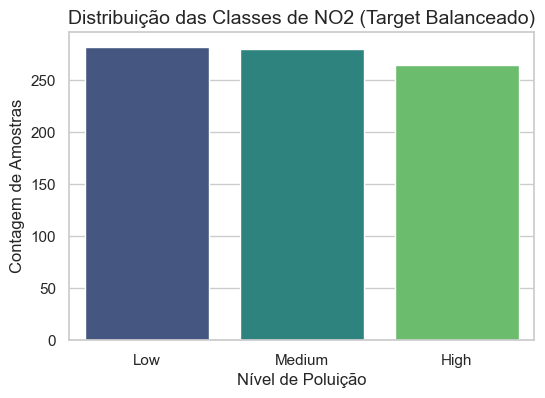

In [4]:
# Criação da variável alvo categorica
air_quality["NO2_class"] = pd.qcut(
    air_quality["NO2(GT)"], 
    q=3, 
    labels=["Low", "Medium", "High"]
)

# Verificação dos intervalos
print("Intervalos de NO2 definidos para cada classe:")
display(air_quality.groupby("NO2_class")["NO2(GT)"].agg(["min", "max", "count"]))

# Visualização da Distribuição
plt.figure(figsize=(6, 4))
sns.countplot(x=air_quality["NO2_class"], palette="viridis")
plt.title("Distribuição das Classes de NO2 (Target Balanceado)")
plt.xlabel("Nível de Poluição")
plt.ylabel("Contagem de Amostras")
savefig("target_distribution")
plt.show()

## 3. Definição de Variáveis e Split
#### **Objetivo:** Separar preditores ($X$) e alvo ($y$) e dividir em treino/teste. O alvo categórico precisa ser convertido para números para os modelos matemáticos.

### 3.1 Seleção de Preditores e Encoding do Alvo
#### **X:** Variáveis numéricas (sensores + meteorologia), excluindo o target original.
#### **y:** Mapeamento de `Low/Medium/High` para inteiros `0, 1, 2`.

In [5]:
target_reg = "NO2(GT)"      # Target numérico original (será descartado de X)
target_class = "NO2_class"  # Novo target categórico

# Seleciona numéricos para X
numeric_cols = air_quality.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_reg]

X = air_quality[feature_cols]
y_cat = air_quality[target_class]

# Converte categorias para códigos inteiros (0, 1, 2)
y_encoded = y_cat.cat.codes.values 
class_names = y_cat.cat.categories.tolist()

print(f"Preditores ({len(feature_cols)}): {feature_cols}")
print(f"Mapeamento de Classes: {dict(enumerate(class_names))}")

Preditores (12): ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Mapeamento de Classes: {0: 'Low', 1: 'Medium', 2: 'High'}


### 3.2 Divisão Treino e Teste (Estratificada)
#### Divisão 75/25.
#### **Importante:** Usamos `stratify=y` para garantir que a proporção de classes (33% cada) seja mantida identicamente nos conjuntos de treino e teste.

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.25, 
    random_state=SEED, 
    stratify=y_encoded # Garante balanço de classes
)

print(f"Dimensões do Treino: {X_train_raw.shape}")
print(f"Dimensões do Teste:  {X_test_raw.shape}")

Dimensões do Treino: (620, 12)
Dimensões do Teste:  (207, 12)


## 4. Pipeline de Pré-processamento
#### **Objetivo:** Preparar os dados para convergência dos algoritmos de gradiente.
#### **Preditores (X):** Log transform (para assimetria) + Z-Score (padronização).
#### **Alvo (y):** One-Hot Encoding necessário para a Rede Neural Manual (vetor de probabilidades).

### 4.1 Implementação do Pipeline
#### A função `process_data_classification` aplica as transformações calculadas no treino e replica no teste para evitar *data leakage*.
#### Gera duas versões de y:
#### 1. `y_train`: Inteiros (0, 1, 2) $\to$ Para Regressão Logística.
#### 2. `y_train_ohe`: Vetores One-Hot (ex: `[0, 1, 0]`) $\to$ Para Rede Neural (MLP).

In [ ]:
def process_data_classification(X_tr, X_ts, y_tr, y_ts):
    # Preditores (X) 
    X_tr_proc = X_tr.copy()
    X_ts_proc = X_ts.copy()
    
    # Log transformation (caso skewness > 0.75)
    skewness = X_tr_proc.skew()
    high_skew = skewness[abs(skewness) > 0.75].index
    
    print(f"Variáveis transformadas (Log): {list(high_skew)}")
    
    for col in high_skew:
        # Garante log em valores positivos
        min_val = min(X_tr_proc[col].min(), X_ts_proc[col].min())
        offset = abs(min_val) + 1 if min_val <= 0 else 0
        X_tr_proc[col] = np.log1p(X_tr_proc[col] + offset)
        X_ts_proc[col] = np.log1p(X_ts_proc[col] + offset)
            
    # Z-Score Normalization
    mean, std = X_tr_proc.mean(), X_tr_proc.std()
    X_tr_norm = (X_tr_proc - mean) / std
    X_ts_norm = (X_ts_proc - mean) / std
    
    # Target (y) para Rede Neural 
    # One-Hot Encoding
    enc = OneHotEncoder(sparse_output=False)
    y_tr_ohe = enc.fit_transform(y_tr.reshape(-1, 1))
    y_ts_ohe = enc.transform(y_ts.reshape(-1, 1))
    
    return X_tr_norm, X_ts_norm, y_tr_ohe, y_ts_ohe

# Execução do Pipeline
X_train_norm, X_test_norm, y_train_ohe, y_test_ohe = process_data_classification(
    X_train_raw, X_test_raw, y_train, y_test
)

print("\nConferência dos Dados Processados")
print(f"X_train (Normalizado): {X_train_norm.shape}")
print(f"y_train (Inteiro - Logistic): {y_train[:3]}")
print(f"y_train (One-Hot - NeuralNet):\n{y_train_ohe[:3]}")

Variáveis transformadas (Log): ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)', 'AH']

--- Conferência dos Dados Processados ---
X_train (Normalizado): (620, 12)
y_train (Inteiro - Logistic): [0 2 1]
y_train (One-Hot - NeuralNet):
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
